In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
df = pd.read_excel("ABC Company.xlsx")

In [3]:
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,2023-02-06 00:00:00,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,2023-06-06 00:00:00,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,2023-05-06 00:00:00,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,2023-05-06 00:00:00,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,2023-10-06 00:00:00,231,NaN,5000000.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    object 
 6   Weight    458 non-null    int64  
 7   College   374 non-null    object 
 8   Salary    447 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 32.3+ KB


In [5]:
df.isnull().sum()

,0
Name,0
Team,0
Number,0
Position,0
Age,0
Height,0
Weight,0
College,84
Salary,11


In [6]:
df["Height"] = np.random.randint(150, 181, size=len(df))

In [7]:
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,164,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,174,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,178,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,165,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,171,231,NaN,5000000.0


In [8]:
team_count = df["Team"].value_counts()

team_count

,count
Team,
New Orleans Pelicans,19
Memphis Grizzlies,18
Utah Jazz,16
Milwaukee Bucks,16
New York Knicks,16
Boston Celtics,15
Los Angeles Clippers,15
Los Angeles Lakers,15
Phoenix Suns,15


In [9]:
team_percentage = (df["Team"].value_counts() / len(df)) * 100

team_percentage

,count
Team,
New Orleans Pelicans,4.148472
Memphis Grizzlies,3.930131
Utah Jazz,3.493450
Milwaukee Bucks,3.493450
New York Knicks,3.493450
Boston Celtics,3.275109
Los Angeles Clippers,3.275109
Los Angeles Lakers,3.275109
Phoenix Suns,3.275109


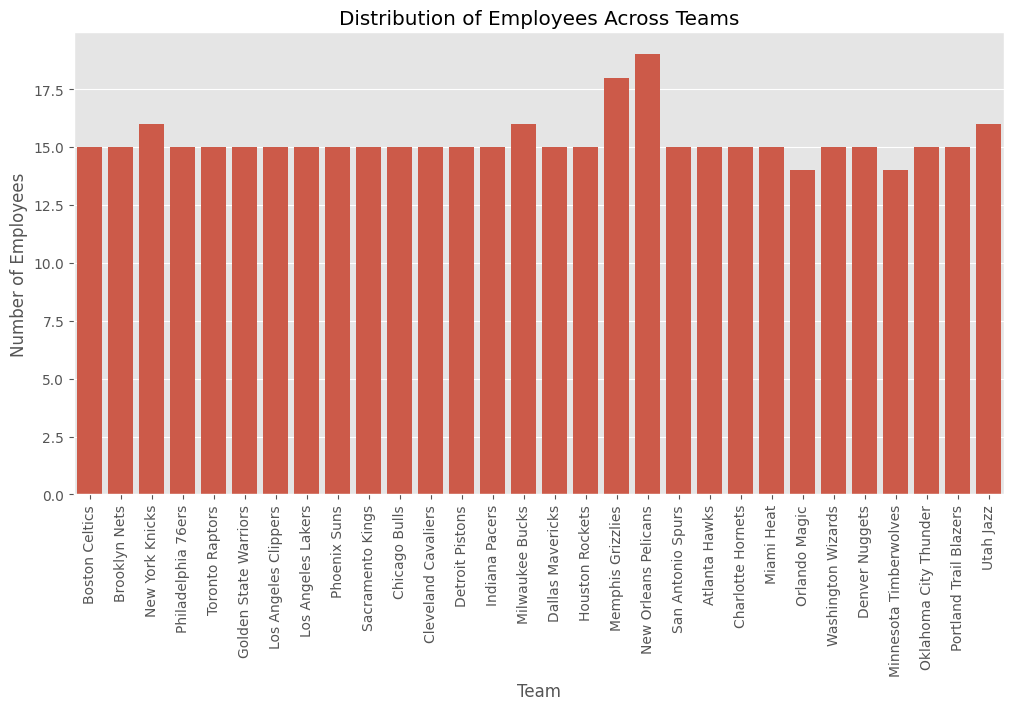

In [10]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="Team")
plt.title("Distribution of Employees Across Teams")
plt.xlabel("Team")
plt.ylabel("Number of Employees")
plt.xticks(rotation=90)
plt.show()

In [11]:
position_count = df["Position"].value_counts()

position_count

,count
Position,
SG,102
PF,100
PG,92
SF,85
C,79


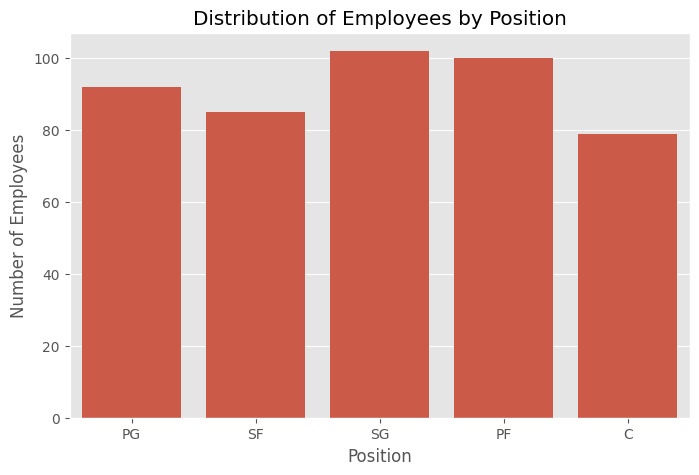

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Position")
plt.title("Distribution of Employees by Position")
plt.xlabel("Position")
plt.ylabel("Number of Employees")
plt.show()

In [13]:
bins = [18, 25, 30, 35, 40, 45, 50]
labels = ["18-25", "26-30", "31-35", "36-40", "41-45", "46-50"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels, include_lowest=True)

age_group_count = df["Age_Group"].value_counts().sort_index()

age_group_count

,count
Age_Group,
18-25,200
26-30,167
31-35,68
36-40,23
41-45,0
46-50,0


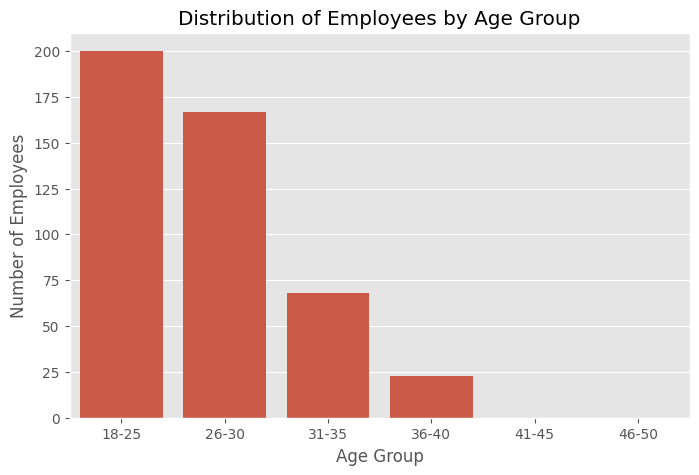

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Age_Group", order=labels)

plt.title("Distribution of Employees by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")

plt.show()

In [15]:
print("Predominant Age Group:", age_group_count.idxmax())
print("Number of Employees:", age_group_count.max())

Predominant Age Group: 18-25
Number of Employees: 200


In [16]:
team_salary = df.groupby("Team")["Salary"].sum()

team_salary

,Salary
Team,
Atlanta Hawks,72902950.0
Boston Celtics,58541068.0
Brooklyn Nets,52528475.0
Charlotte Hornets,78340920.0
Chicago Bulls,86783378.0
Cleveland Cavaliers,106988689.0
Dallas Mavericks,71198732.0
Denver Nuggets,60121930.0
Detroit Pistons,67168263.0


In [17]:
print("Team with Highest Salary Expenditure:")
print(team_salary.idxmax())

print("\nTotal Salary:")
print(team_salary.max())

Team with Highest Salary Expenditure:
Cleveland Cavaliers

Total Salary:
106988689.0


In [18]:
position_salary = df.groupby("Position")["Salary"].sum()

position_salary

,Salary
Position,
C,466377332.0
PF,442560850.0
PG,446848971.0
SF,408020976.0
SG,396976258.0


In [19]:
print("Position with Highest Salary Expenditure:")
print(position_salary.idxmax())

print("\nTotal Salary:")
print(position_salary.max())

Position with Highest Salary Expenditure:
C

Total Salary:
466377332.0


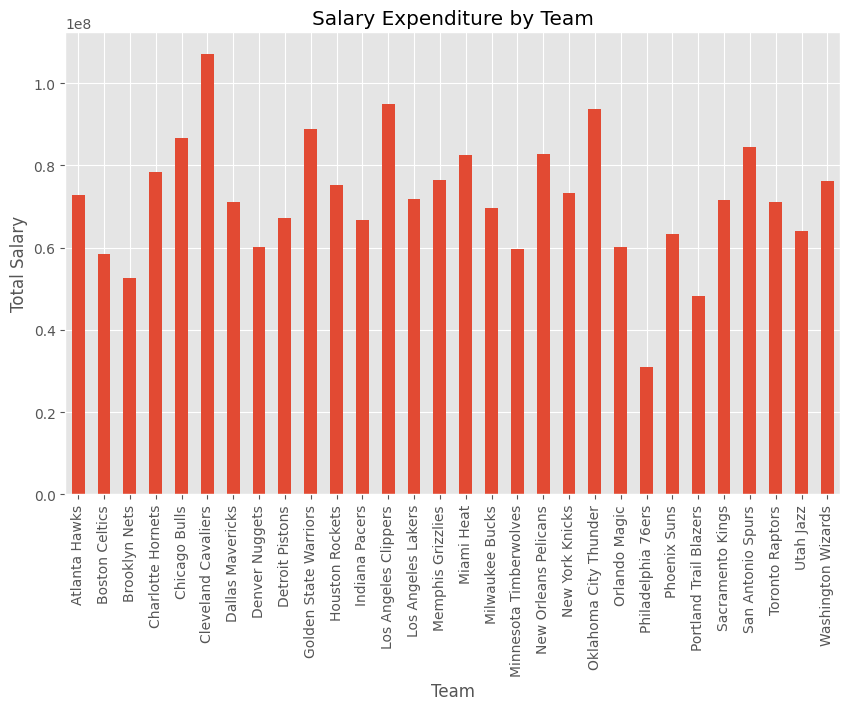

In [20]:
plt.figure(figsize=(10,6))
team_salary.plot(kind="bar")

plt.title("Salary Expenditure by Team")
plt.xlabel("Team")
plt.ylabel("Total Salary")

plt.xticks(rotation=90)
plt.show()

In [21]:
correlation = df["Age"].corr(df["Salary"])

print("Correlation between Age and Salary:", correlation)

Correlation between Age and Salary: 0.21400941226570971


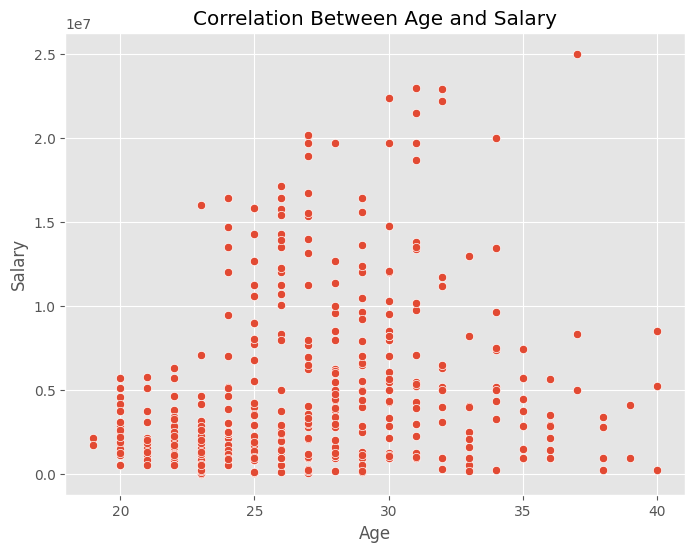

In [22]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Age", y="Salary")

plt.title("Correlation Between Age and Salary")
plt.xlabel("Age")
plt.ylabel("Salary")

plt.show()

The employee data of ABC Company was looked at after changing the Height column with numbers between 150 cm and 180 cm. This was done to see how employees are spread out across teams and positions.

Most employees of ABC Company are between 26 and 30 years old.

The team with the salary expenditure at ABC Company is the team that spends the most money on salaries.

The position that gets the total salary at ABC Company is the one that receives the most money.

When we look at the connection between age and salary of employees at ABC Company we see that it is not very strong which means that salary is not mostly based on age.

Overall looking at the employee data of ABC Company provides information, about how employees are distributed and how salaries are given at ABC Company.